# Análisis de Sincronización: Hilbert + Kuramoto + Joint Recurrence Plots (Lorenz Delayed) - Output

Results of the synchronization analysis between a Lorenz time series and its delayed version.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Publication-quality figure settings
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.size': 4,
    'ytick.major.width': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': 'black',
    'lines.linewidth': 1.0,
    'lines.markersize': 4
})
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Load saved results
results_df = pd.read_parquet('../data/kuramoto_jrp_lag_sweep_lorenz_delayed.parquet')
print(f'Loaded {len(results_df)} lag points')
print(results_df.head())

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Loaded 601 lag points
   lag  lag_sec    r_mean     r_std  frac_above_07  max_sustained_tu  \
0 -300    -3.00  0.621510  0.275286       0.462791              3.08   
1 -299    -2.99  0.621253  0.275832       0.460363              3.07   
2 -298    -2.98  0.620942  0.276668       0.455649              3.06   
3 -297    -2.97  0.620619  0.277694       0.455221              3.06   
4 -296    -2.96  0.620252  0.278972       0.453649              3.05   

     jrp_RR   jrp_DET   jrp_LAM  jrp_max_diag  kuramoto_score  jrp_score  \
0  0.011602  0.940786  0.975589          6999        0.001664        0.0   
1  0.000000  0.000000  0.000000             0        0.001362        0.0   
2  0.000000  0.000000  0.000000             0        0.000798        0.0   
3  0.000000  0.000000  0.000000             0        0.000738        0.0   
4  0.000000  0.000000  0.000000             0        0.000550        0.0   

   combined_score  
0        0.000832  
1        0.000681  
2        0.000399  
3       

In [2]:
# Summary statistics
best_kuramoto = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])
best_kuramoto_sustained = results_df.loc[results_df['kuramoto_score'].idxmax(), 'max_sustained_tu']
best_kuramoto_frac = results_df.loc[results_df['kuramoto_score'].idxmax(), 'frac_above_07']
best_kuramoto_r = results_df.loc[results_df['kuramoto_score'].idxmax(), 'r_mean']

jrp_valid = results_df[(results_df['lag'] != -results_df['lag'].max()) & (results_df['lag'] != results_df['lag'].max()) & (results_df['jrp_RR'] > 0)].copy()

# JRP score: Recurrence Rate (RR) as sole criterion
def normalize(series):
    min_v, max_v = series.min(), series.max()
    if max_v > min_v:
        return (series - min_v) / (max_v - min_v)
    return series * 0

jrp_valid['jrp_RR_norm'] = normalize(jrp_valid['jrp_RR'])
best_jrp = int(jrp_valid.loc[jrp_valid['jrp_RR_norm'].idxmax(), 'lag']) if len(jrp_valid) > 0 else 'N/A'
best_combined = int(results_df.loc[results_df['combined_score'].idxmax(), 'lag'])

print('=== FINAL SUMMARY ===')
print(f'True delay:                                         150 steps (1.50 t.u.)')
print(f'Best lag (Kuramoto - frac_above_07 × r_mean):     {best_kuramoto} steps ({best_kuramoto/100:.2f} t.u.)  [max_sustained={best_kuramoto_sustained:.2f} t.u., frac_above_07={best_kuramoto_frac:.3f}, r_mean={best_kuramoto_r:.4f}]')
print(f'Best lag (JRP - RR only, excl. extreme lags):    {best_jrp} steps ({best_jrp/100:.2f} t.u.)')
print(f'Best lag (Combined):                               {best_combined} steps ({best_combined/100:.2f} t.u.)')

error_kuramoto = abs(best_kuramoto - 150) / 100
error_jrp = abs(best_jrp - 150) / 100 if best_jrp != 'N/A' else 'N/A'
error_combined = abs(best_combined - 150) / 100
print(f'\nErrors vs true delay:')
print(f'  Kuramoto:  {error_kuramoto:.2f} t.u.')
print(f'  JRP (RR):  {error_jrp:.2f} t.u.' if error_jrp != 'N/A' else '  JRP (RR):       N/A')
print(f'  Combined:  {error_combined:.2f} t.u.')

=== FINAL SUMMARY ===
True delay:                                         150 steps (1.50 t.u.)
Best lag (Kuramoto - frac_above_07 × r_mean):     150 steps (1.50 t.u.)  [max_sustained=70.01 t.u., frac_above_07=1.000, r_mean=1.0000]
Best lag (JRP - RR only, excl. extreme lags):    150 steps (1.50 t.u.)
Best lag (Combined):                               150 steps (1.50 t.u.)

Errors vs true delay:
  Kuramoto:  0.00 t.u.
  JRP (RR):  0.00 t.u.
  Combined:  0.00 t.u.


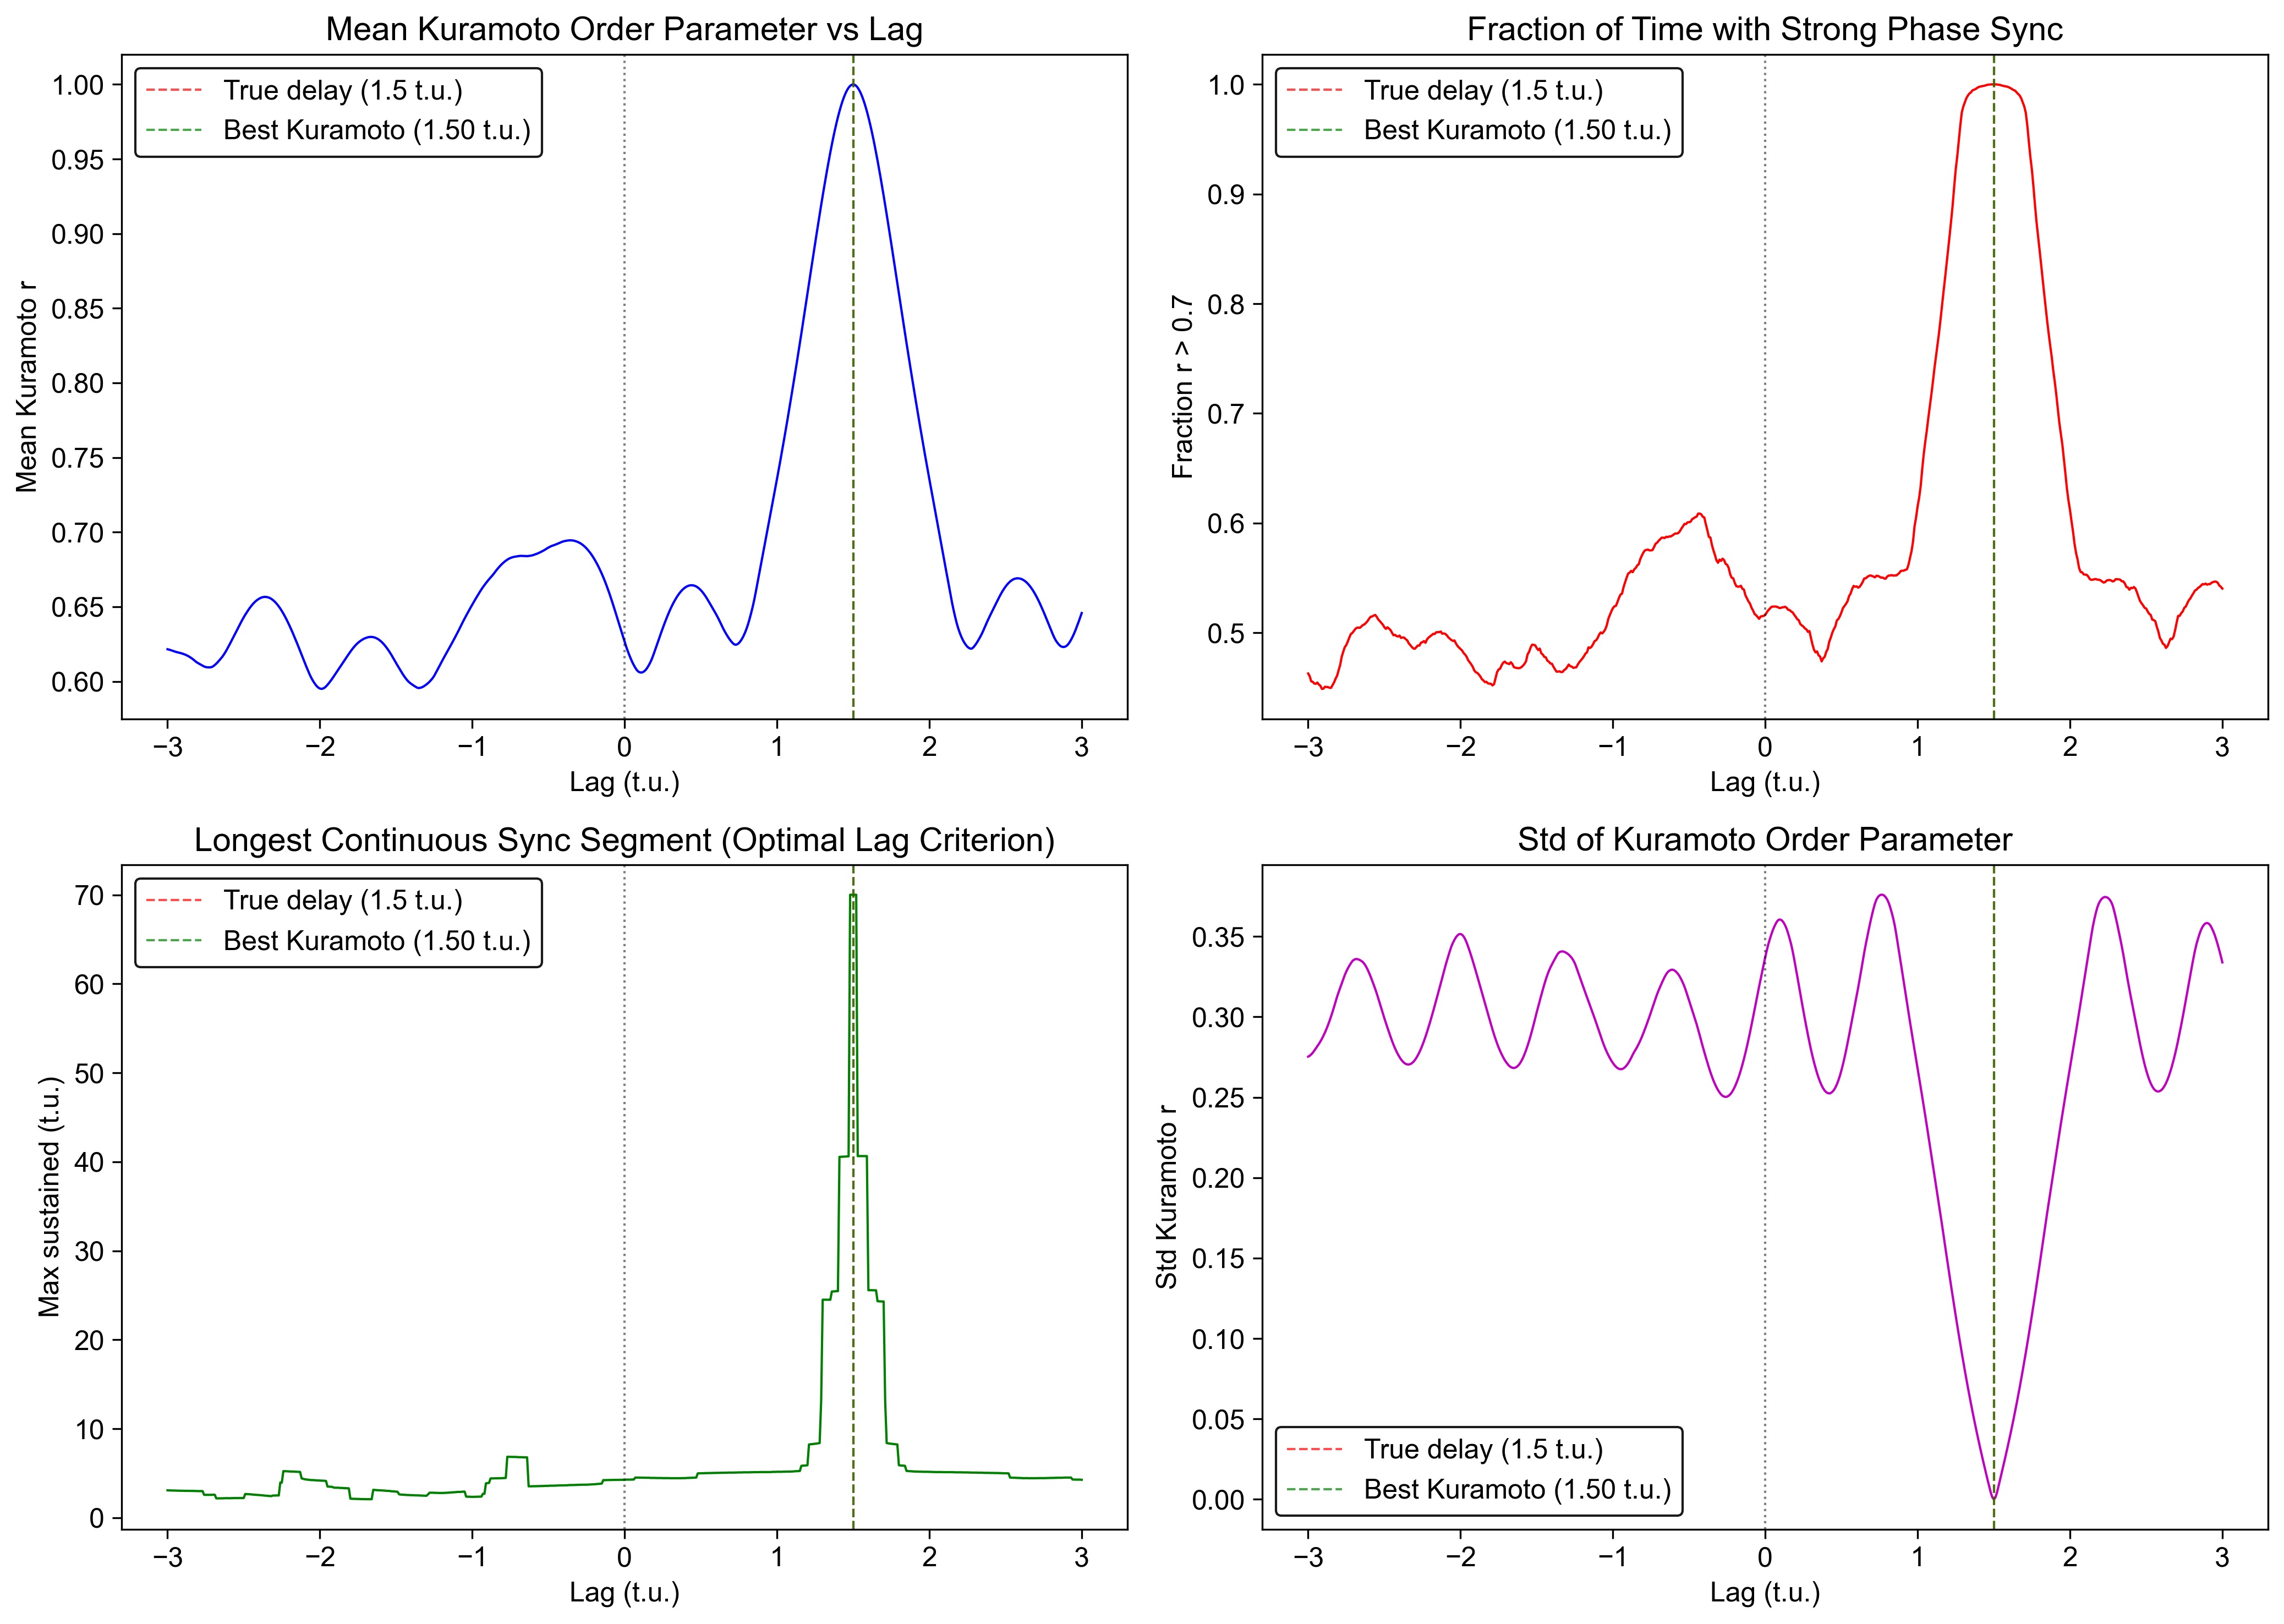

In [3]:
# Plot Kuramoto metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes[0, 0].plot(results_df['lag_sec'], results_df['r_mean'], 'b-', linewidth=1)
axes[0, 0].set_xlabel('Lag (t.u.)')
axes[0, 0].set_ylabel('Mean Kuramoto r')
axes[0, 0].set_title('Mean Kuramoto Order Parameter vs Lag')
axes[0, 0].grid(False)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5 t.u.)')
axes[0, 0].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto/100:.2f} t.u.)')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[0, 1].plot(results_df['lag_sec'], results_df['frac_above_07'], 'r-', linewidth=1)
axes[0, 1].set_xlabel('Lag (t.u.)')
axes[0, 1].set_ylabel('Fraction r > 0.7')
axes[0, 1].set_title('Fraction of Time with Strong Phase Sync')
axes[0, 1].grid(False)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5 t.u.)')
axes[0, 1].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto/100:.2f} t.u.)')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 0].plot(results_df['lag_sec'], results_df['max_sustained_tu'], 'g-', linewidth=1)
axes[1, 0].set_xlabel('Lag (t.u.)')
axes[1, 0].set_ylabel('Max sustained (t.u.)')
axes[1, 0].set_title('Longest Continuous Sync Segment (Optimal Lag Criterion)')
axes[1, 0].grid(False)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5 t.u.)')
axes[1, 0].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto/100:.2f} t.u.)')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 1].plot(results_df['lag_sec'], results_df['r_std'], 'm-', linewidth=1)
axes[1, 1].set_xlabel('Lag (t.u.)')
axes[1, 1].set_ylabel('Std Kuramoto r')
axes[1, 1].set_title('Std of Kuramoto Order Parameter')
axes[1, 1].grid(False)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5 t.u.)')
axes[1, 1].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto/100:.2f} t.u.)')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

plt.tight_layout()
plt.show()

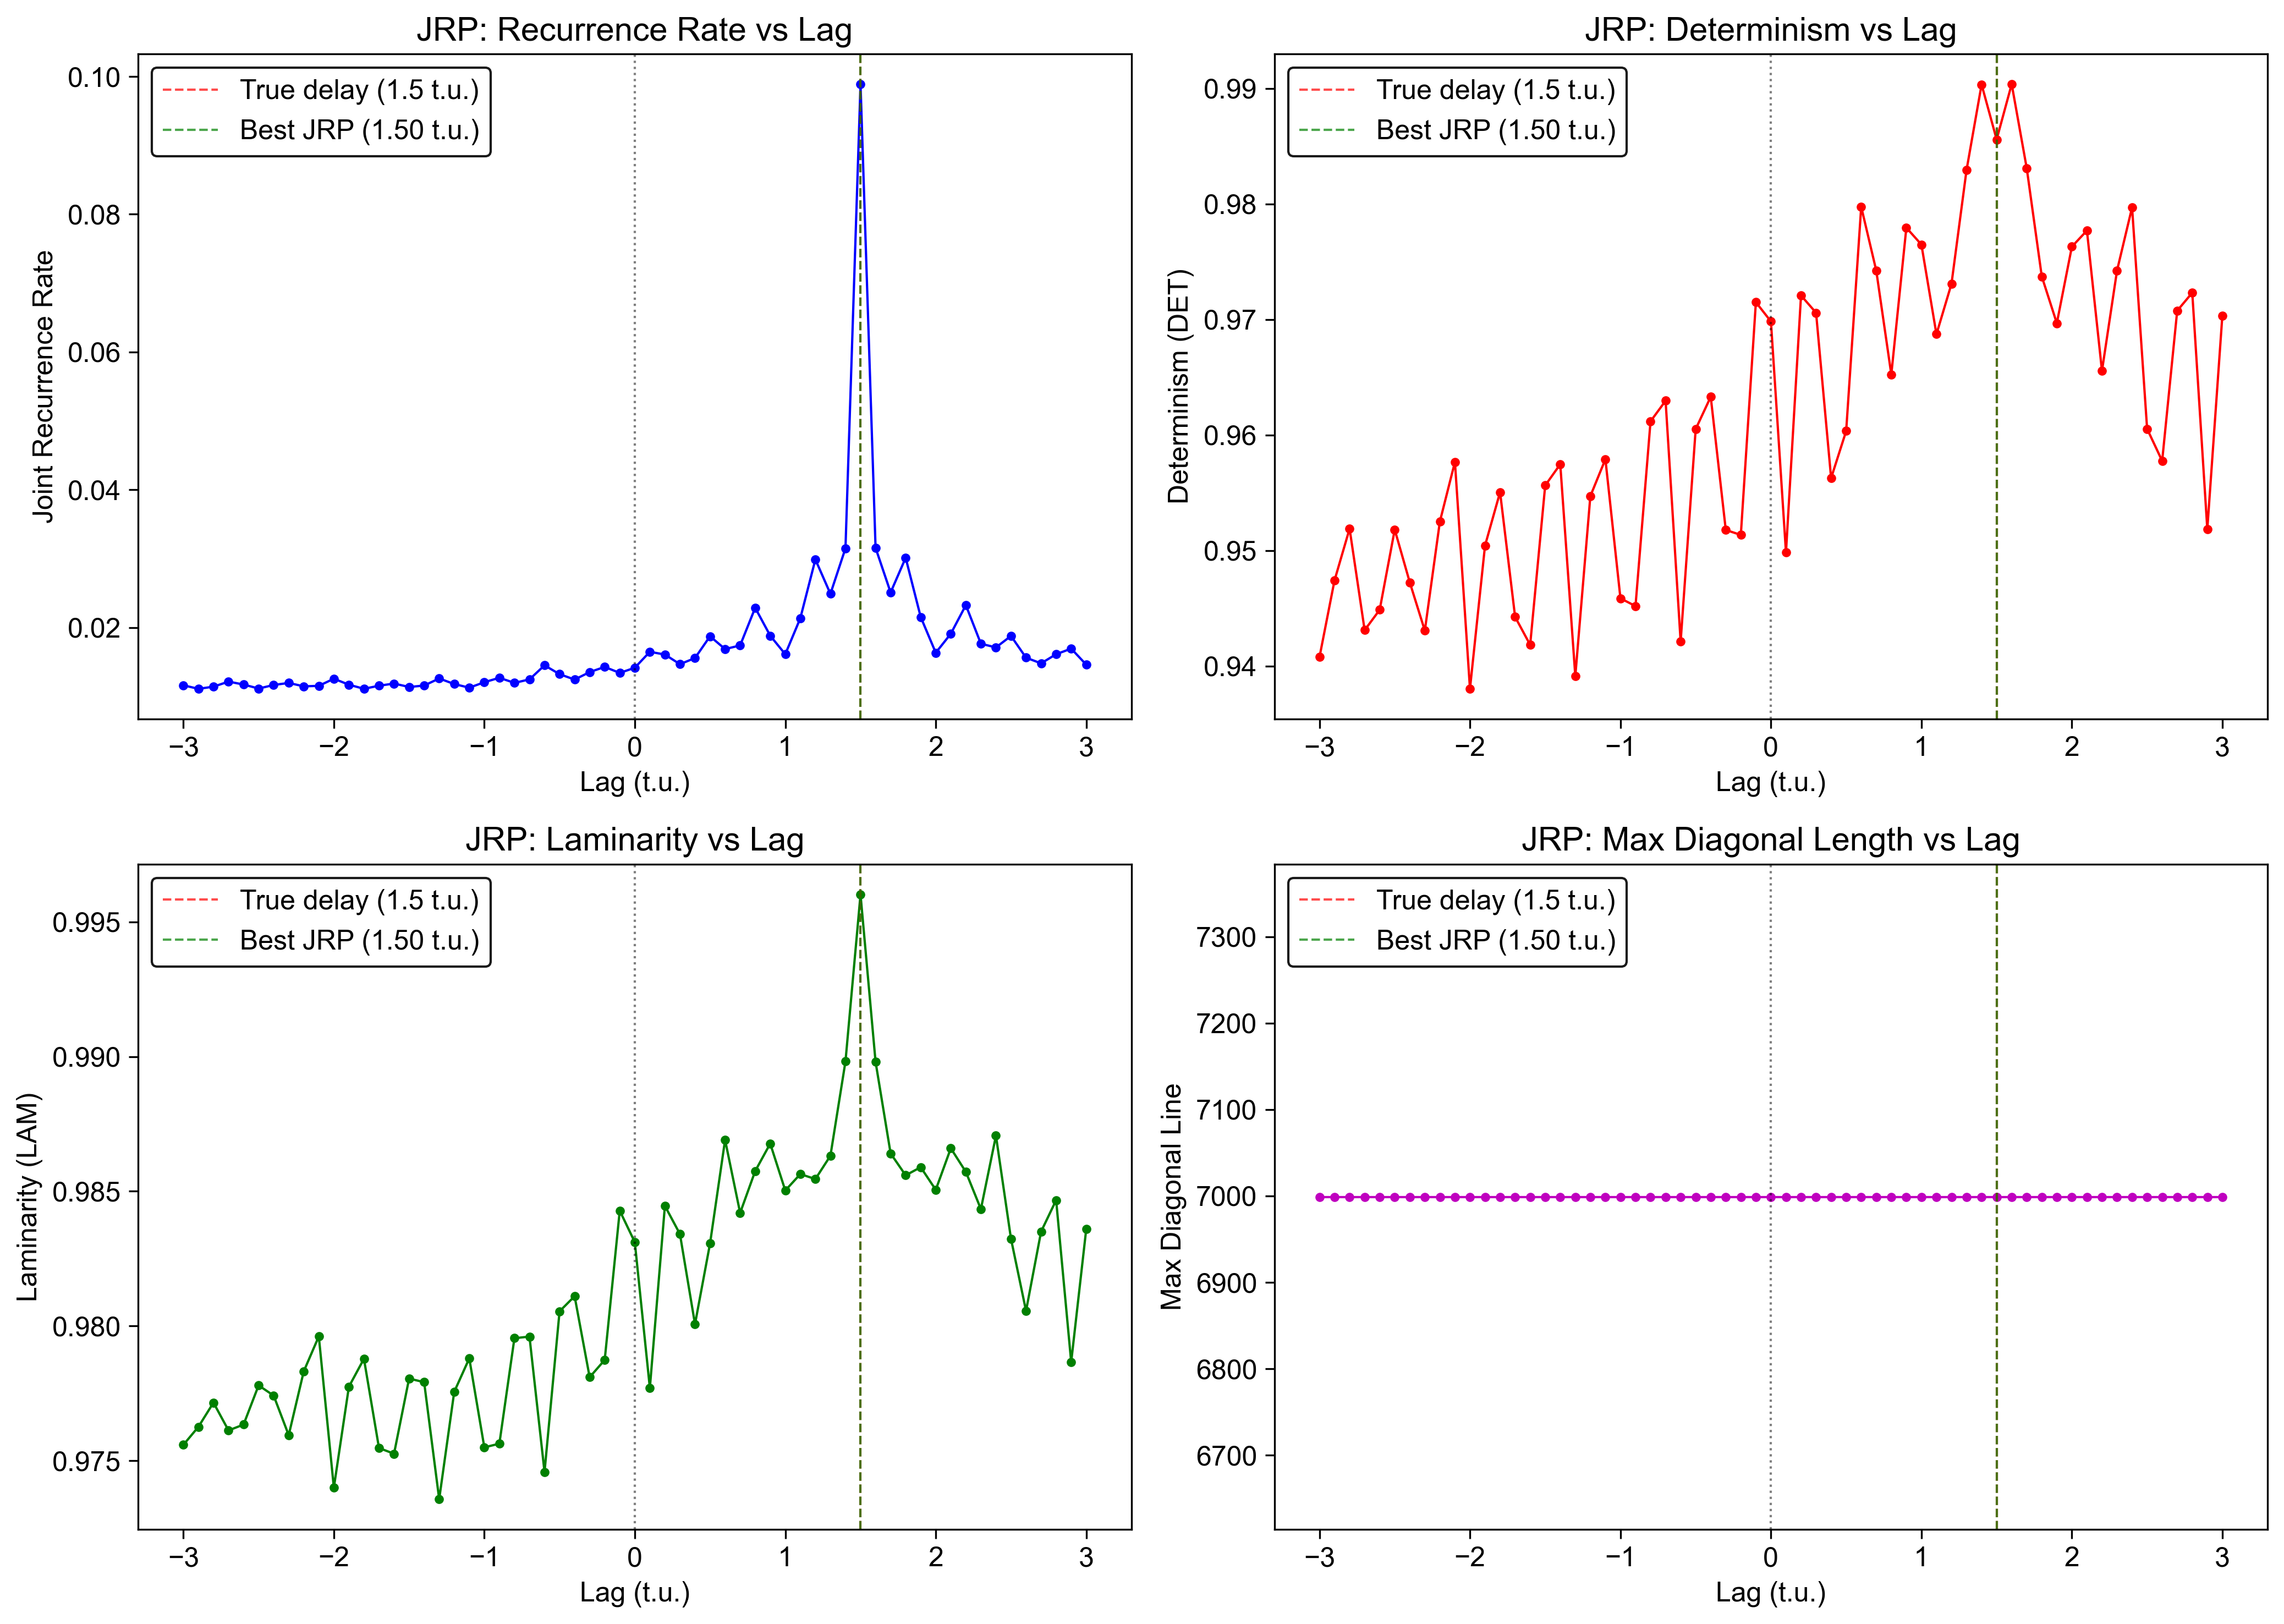

In [4]:
# Plot JRP metrics
jrp_df = results_df[results_df['jrp_RR'] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes[0, 0].plot(jrp_df['lag_sec'], jrp_df['jrp_RR'], 'b-o', linewidth=1, markersize=3)
axes[0, 0].set_xlabel('Lag (t.u.)')
axes[0, 0].set_ylabel('Joint Recurrence Rate')
axes[0, 0].set_title('JRP: Recurrence Rate vs Lag')
axes[0, 0].grid(False)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5 t.u.)')
if best_jrp != 'N/A':
    axes[0, 0].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp/100:.2f} t.u.)')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[0, 1].plot(jrp_df['lag_sec'], jrp_df['jrp_DET'], 'r-o', linewidth=1, markersize=3)
axes[0, 1].set_xlabel('Lag (t.u.)')
axes[0, 1].set_ylabel('Determinism (DET)')
axes[0, 1].set_title('JRP: Determinism vs Lag')
axes[0, 1].grid(False)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5 t.u.)')
if best_jrp != 'N/A':
    axes[0, 1].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp/100:.2f} t.u.)')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 0].plot(jrp_df['lag_sec'], jrp_df['jrp_LAM'], 'g-o', linewidth=1, markersize=3)
axes[1, 0].set_xlabel('Lag (t.u.)')
axes[1, 0].set_ylabel('Laminarity (LAM)')
axes[1, 0].set_title('JRP: Laminarity vs Lag')
axes[1, 0].grid(False)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5 t.u.)')
if best_jrp != 'N/A':
    axes[1, 0].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp/100:.2f} t.u.)')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 1].plot(jrp_df['lag_sec'], jrp_df['jrp_max_diag'], 'm-o', linewidth=1, markersize=3)
axes[1, 1].set_xlabel('Lag (t.u.)')
axes[1, 1].set_ylabel('Max Diagonal Line')
axes[1, 1].set_title('JRP: Max Diagonal Length vs Lag')
axes[1, 1].grid(False)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5 t.u.)')
if best_jrp != 'N/A':
    axes[1, 1].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp/100:.2f} t.u.)')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

plt.tight_layout()
plt.show()

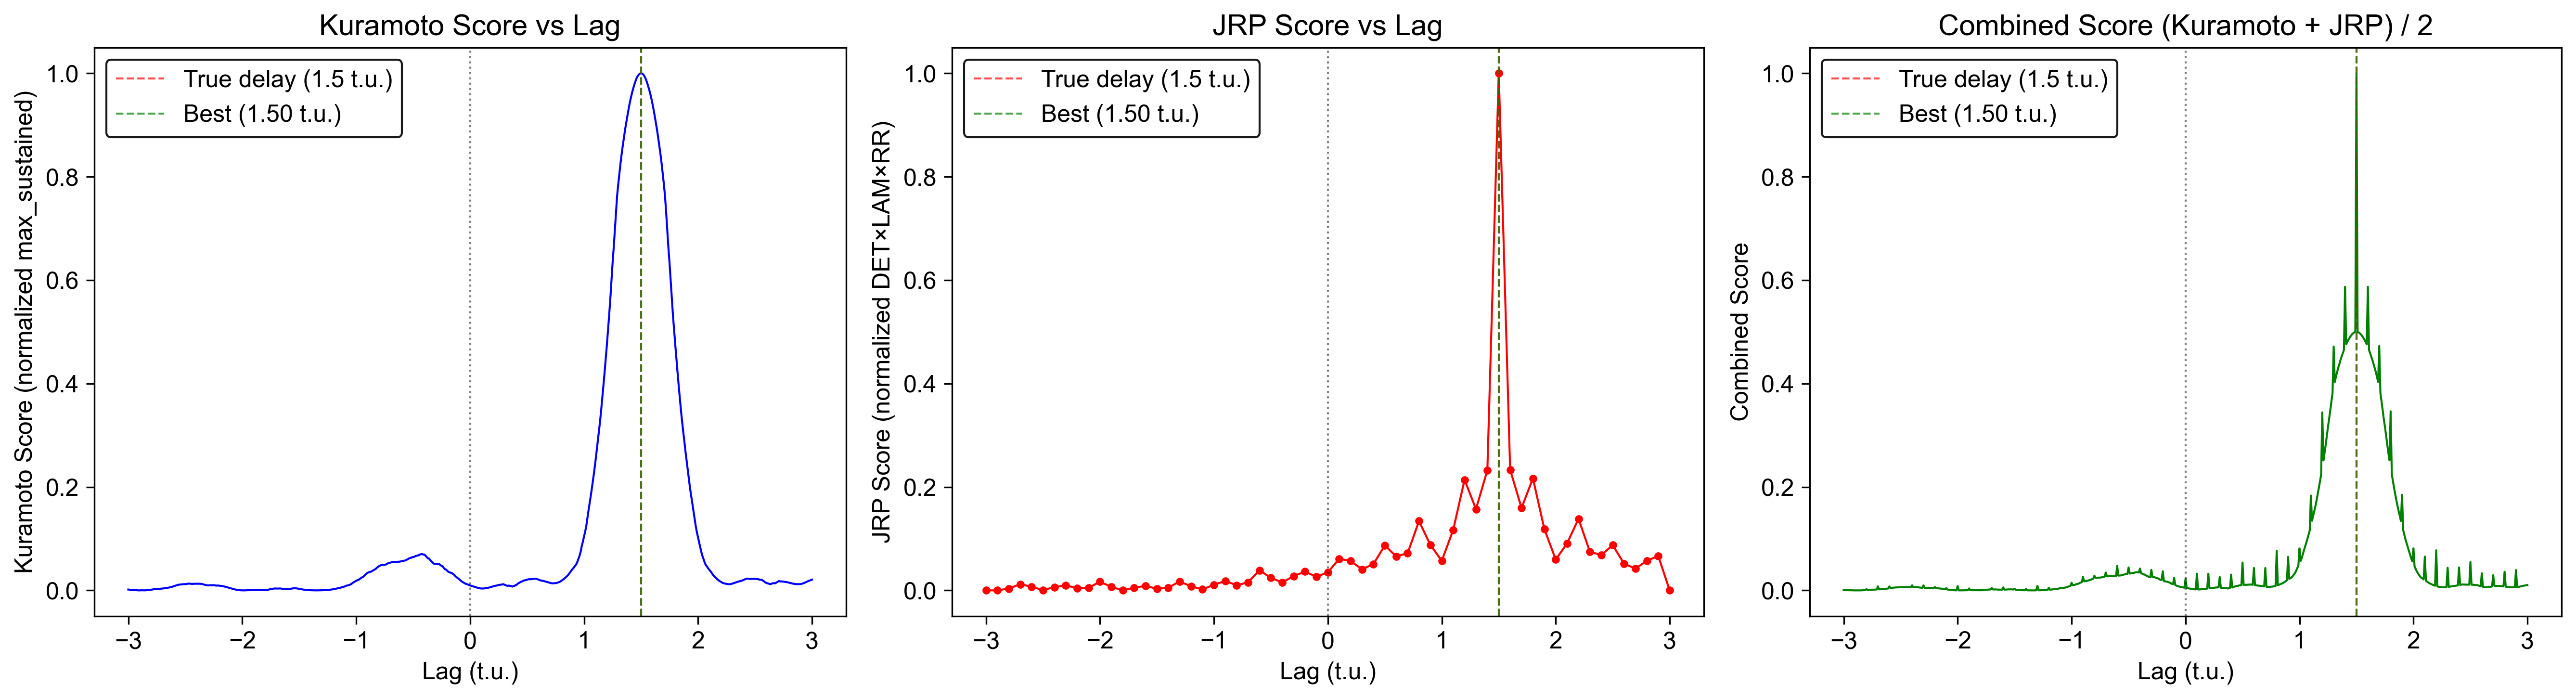

In [6]:
# Combined scores plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

axes[0].plot(results_df['lag_sec'], results_df['kuramoto_score'], 'b-', linewidth=1)
axes[0].set_xlabel('Lag (t.u.)')
axes[0].set_ylabel('Kuramoto Score (normalized max_sustained)')
axes[0].set_title('Kuramoto Score vs Lag')
axes[0].grid(False)
axes[0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5 t.u.)')
axes[0].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_kuramoto/100:.2f} t.u.)')
axes[0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1].plot(jrp_df['lag_sec'], jrp_df['jrp_score'], 'r-o', linewidth=1, markersize=3)
axes[1].set_xlabel('Lag (t.u.)')
axes[1].set_ylabel('JRP Score (normalized DET×LAM×RR)')
axes[1].set_title('JRP Score vs Lag')
axes[1].grid(False)
axes[1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5 t.u.)')
if best_jrp != 'N/A':
    axes[1].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_jrp/100:.2f} t.u.)')
axes[1].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[2].plot(results_df['lag_sec'], results_df['combined_score'], 'g-', linewidth=1)
axes[2].set_xlabel('Lag (t.u.)')
axes[2].set_ylabel('Combined Score')
axes[2].set_title('Combined Score (Kuramoto + JRP) / 2')
axes[2].grid(False)
axes[2].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[2].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5 t.u.)')
axes[2].axvline(x=best_combined/100, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_combined/100:.2f} t.u.)')
axes[2].legend(frameon=True, framealpha=0.9, edgecolor="black")

plt.tight_layout()
plt.show()

In [8]:
# Top 10 results
print('=== Top 10 by Kuramoto Score (frac_above_07 × r_mean) ===')
print(results_df.nlargest(10, 'kuramoto_score')[['lag_sec', 'r_mean', 'frac_above_07', 'max_sustained_tu', 'kuramoto_score']].to_string(index=False))

jrp_valid = results_df[(results_df['lag'] != -results_df['lag'].max()) & (results_df['lag'] != results_df['lag'].max()) & (results_df['jrp_RR'] > 0)].copy()
print('\n=== Top 10 by JRP Score (RR only, excl. extreme lags) ===')
print(jrp_valid.nlargest(10, 'jrp_score')[["lag_sec", "jrp_RR", "jrp_DET", "jrp_LAM", "jrp_max_diag", "jrp_score"]].to_string(index=False))

print('\n=== Top 10 by Combined Score ===')
print(results_df.nlargest(10, 'combined_score')[['lag_sec', 'r_mean', 'frac_above_07', 'max_sustained_tu', 'jrp_RR', 'jrp_DET', 'combined_score']].to_string(index=False))

=== Top 10 by Kuramoto Score (frac_above_07 × r_mean) ===
 lag_sec   r_mean  frac_above_07  max_sustained_tu  kuramoto_score
    1.50 0.999985       1.000000             70.01        1.000000
    1.51 0.999737       1.000000             70.01        0.999387
    1.49 0.999733       1.000000             70.01        0.999377
    1.52 0.998995       1.000000             70.01        0.997555
    1.48 0.998990       1.000000             70.01        0.997543
    1.47 0.997782       0.999857             40.61        0.994303
    1.53 0.997785       0.999714             40.64        0.994051
    1.46 0.996133       0.999714             40.60        0.989976
    1.54 0.996133       0.999571             40.64        0.989720
    1.45 0.994063       0.999286             40.59        0.984101

=== Top 10 by JRP Score (RR only, excl. extreme lags) ===
 lag_sec   jrp_RR  jrp_DET  jrp_LAM  jrp_max_diag  jrp_score
     1.5 0.098888 0.985592 0.996016          6999   1.000000
     1.6 0.031559 0.9903